# 01 — Exploratory Data Analysis: Chilean Port Congestion (2005–2025)

**Master's Thesis · Waze Cargo Project**
**Notebook 1 of 8 — Foundation EDA**

---

## 1.1  Purpose of this notebook

This notebook is the **foundation** for every ML model that is evaluated in
notebooks `02` through `08`. It answers the questions a thesis examiner will ask
*before* looking at a single model:

| # | Question | Where it is answered |
|---|----------|----------------------|
| 1 | What is the unit of analysis? | §2 — Data dictionary |
| 2 | What does the target variable look like? | §3 — Target inspection |
| 3 | Is the data clean enough to model? | §4 — Quality / missingness |
| 4 | Are there structural breaks (COVID, 2024)? | §5 — Temporal anomalies |
| 5 | Which features carry signal vs. noise? | §6 — Univariate inspection |
| 6 | How do the features relate to each other? | §7 — Correlation structure |
| 7 | Is the series stationary / seasonal? | §8 — Time-series diagnostics |
| 8 | Which ports / cargo flows matter most? | §9 — Port-level segmentation |
| 9 | What is a fair train/test split? | §10 — Walk-forward design |

## 1.2  Domain context

Chilean foreign trade is dominated by **78 port–direction pairs** (45 physical
ports × {import, export}). Customs (Servicio Nacional de Aduanas) publishes
*every shipment* with year, month, cargo type, weight, value, HS code and
counter-party country. Aggregated to **monthly** granularity, those records
form a panel of **22,144 port-month observations** spanning 2005–2025.

The downstream ML task is **forecasting the number of shipments per port per
month for 2026** — a quantity highly correlated with physical congestion (waiting
ships, dwell time, terminal saturation). The full congestion index used in
production combines four normalised signals:

$$
\text{cong}_{t}^{\,imp} \;=\; 0.40\;\widetilde{\text{ships}}_{t}
                        \;+\; 0.30\;\widetilde{\text{value}}_{t}
                        \;+\; 0.20\;\widetilde{\text{div}}_{t}
                        \;+\; 0.10\;\text{pct\_container}_{t}
$$

$$
\text{cong}_{t}^{\,exp} \;=\; 0.40\;\widetilde{\text{weight}}_{t}
                        \;+\; 0.30\;\widetilde{\text{ships}}_{t}
                        \;+\; 0.20\;\widetilde{\text{value}}_{t}
                        \;+\; 0.10\;\text{pct\_refrig}_{t}
$$

where $\widetilde{x}$ denotes **min-max normalisation** within a single
port-direction series, so each component lies in $[0,1]$ and the index is
bounded by $[0,1]$ as well. The ML target during training is the *raw*
`shipment_count` (a count variable, sub-component of the index) because:
1. It is the easiest signal to validate against external sources (port records).
2. It feeds the most heavily-weighted normalised term in the index.
3. Once forecast, all the remaining components can be derived deterministically
   from per-port historical ratios.


In [1]:
# ── Imports & global config ────────────────────────────────────────
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams.update({
    "figure.figsize": (11, 5),
    "figure.dpi":     110,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "savefig.bbox":   "tight",
})

DATA_DIR = Path("data")
FIG_DIR  = Path("figures"); FIG_DIR.mkdir(exist_ok=True)
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Notebook environment ready.")


Notebook environment ready.


## 2  Data dictionary

The cache produced by `build_feature_cache.py` materialises **two parquet files**
that mirror the production PostgreSQL tables:

| File | Rows | Description |
|------|------|-------------|
| `port_monthly_agg.parquet`      | 22 144 | Raw monthly aggregates per port × direction × aduana |
| `port_features_indexed.parquet` | 21 013 | + lag, rolling, COVID flags, normalised congestion components |

`port_features_indexed` already drops the rows where `lag_1` or `lag_12` is
null (i.e. the first 12 months of every series), which is why its row count is
≈ 1 100 lower than the aggregate.


In [2]:
# ── Load both tables ───────────────────────────────────────────────
agg  = pd.read_parquet(DATA_DIR / "port_monthly_agg.parquet")
feat = pd.read_parquet(DATA_DIR / "port_features_indexed.parquet")
meta = json.loads((DATA_DIR / "meta.json").read_text())

print(f"port_monthly_agg      : {len(agg):>7,} rows × {len(agg.columns)} cols")
print(f"port_features_indexed : {len(feat):>7,} rows × {len(feat.columns)} cols")
print(f"\nUnique ports             : {feat['port'].nunique()}")
print(f"Unique port-direction    : {feat.groupby(['port','direction']).ngroups}")
print(f"Year range               : {feat['year'].min()} – {feat['year'].max()}")
print(f"COVID years (flagged)    : {meta['covid_years']}")
print(f"Incomplete year (excl.)  : {meta['incomplete_years']}")


port_monthly_agg      :  22,144 rows × 22 cols
port_features_indexed :  21,013 rows × 55 cols

Unique ports             : 45
Unique port-direction    : 78
Year range               : 2005 – 2025
COVID years (flagged)    : [2020, 2021, 2022]
Incomplete year (excl.)  : [2024]


In [3]:
# ── Show the schema in a tidy table ───────────────────────────────
schema = pd.DataFrame({
    "column":   feat.columns,
    "dtype":    feat.dtypes.astype(str).values,
    "n_null":   feat.isna().sum().values,
    "n_unique": feat.nunique().values,
    "example":  [feat[c].dropna().iloc[0] if feat[c].notna().any() else None
                 for c in feat.columns],
})
schema["pct_null"] = (schema["n_null"] / len(feat) * 100).round(2)
schema[["column","dtype","n_null","pct_null","n_unique","example"]]


,column,dtype,n_null,pct_null,n_unique,example
0,year,int32,0,0.00,21,2005
1,month,int32,0,0.00,12,6
2,port,str,0,0.00,45,AEROP. A.M. BENITEZ
3,direction,str,0,0.00,2,export
4,aduana,str,0,0.00,16,Metropolitana
5,shipment_count,int64,0,0.00,2129,5
6,total_value_usd,float64,0,0.00,11547,864.0
7,total_weight_mt,float64,8814,41.95,10745,0.142
8,total_quantity,float64,0,0.00,17029,3236.0
9,commodity_diversity,int64,0,0.00,97,4


### 2.1  Schema interpretation

The 55 columns of `port_features_indexed` fall into **eight functional groups**:

| Group | Columns | Role in modelling |
|-------|---------|-------------------|
| **Identifiers** | `port`, `direction`, `aduana`, `year`, `month` | Panel keys, never features |
| **Targets / aggregates** | `shipment_count`, `total_value_usd`, `total_weight_mt`, `total_quantity` | `shipment_count` is the supervised target |
| **Diversity** | `commodity_diversity`, `hs4_diversity`, `country_diversity`, `continent_diversity` | Proxy for cargo mix complexity |
| **Cargo mix** | `pct_general`, `pct_bulk`, `pct_refrigerated`, `pct_container` | Composition; sums to ≈ 1 |
| **Lags** | `lag_1`, `lag_2`, `lag_3`, `lag_12`, `lag_value_12`, `lag_weight_12`, `lag_12_clean` | Temporal memory; `lag_12_clean` repairs COVID-tainted lookbacks |
| **Rolling stats** | `rolling_3_mean`, `rolling_12_mean`, `rolling_value_12_mean` | Smoothed trend |
| **Calendar** | `month_sin`, `month_cos`, `quarter`, `year_index`, `season` | Seasonality (sin/cos avoids the 12→1 discontinuity) |
| **Growth & norms** | `yoy_growth`, `yoy_growth_clean`, `yoy_value_growth`, `sc_norm`, `v_norm`, `w_norm`, `cd_norm` | Pace of change; normalisations feed the congestion index |
| **COVID flags** | `is_covid_shock`, `is_covid_rebound`, `is_covid_aftershock`, `lag_12_is_covid` | Binary indicators that let trees split out the structural break |

Note that the **dominant_*** columns are `VARCHAR` and **never** become features
(LightGBM would need explicit categorical handling — instead they are kept for
interpretation only).


## 3  Target variable inspection — `shipment_count`

Three things must be true for `shipment_count` to be a defensible regression
target:

1. The distribution is **strictly positive** (no zeros / negatives that would
   break MAPE).
2. The variance is large enough that explaining it is non-trivial.
3. There is a *natural unit of dispersion* (heavy right tail typical of port
   data → log transformation often improves linear baselines).


In [4]:
# ── Target descriptive statistics ─────────────────────────────────
desc = feat.groupby("direction")["shipment_count"].describe(
    percentiles=[0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
).round(1)
desc


,count,mean,std,min,5%,25%,50%,75%,95%,99%,max
direction,,,,,,,,,,,
export,12199.0,325.6,1256.1,1.0,1.0,3.0,7.0,48.0,1202.3,7265.5,9723.0
import,8814.0,1524.1,6748.8,1.0,1.0,2.0,7.0,53.0,14847.1,31217.3,105852.0


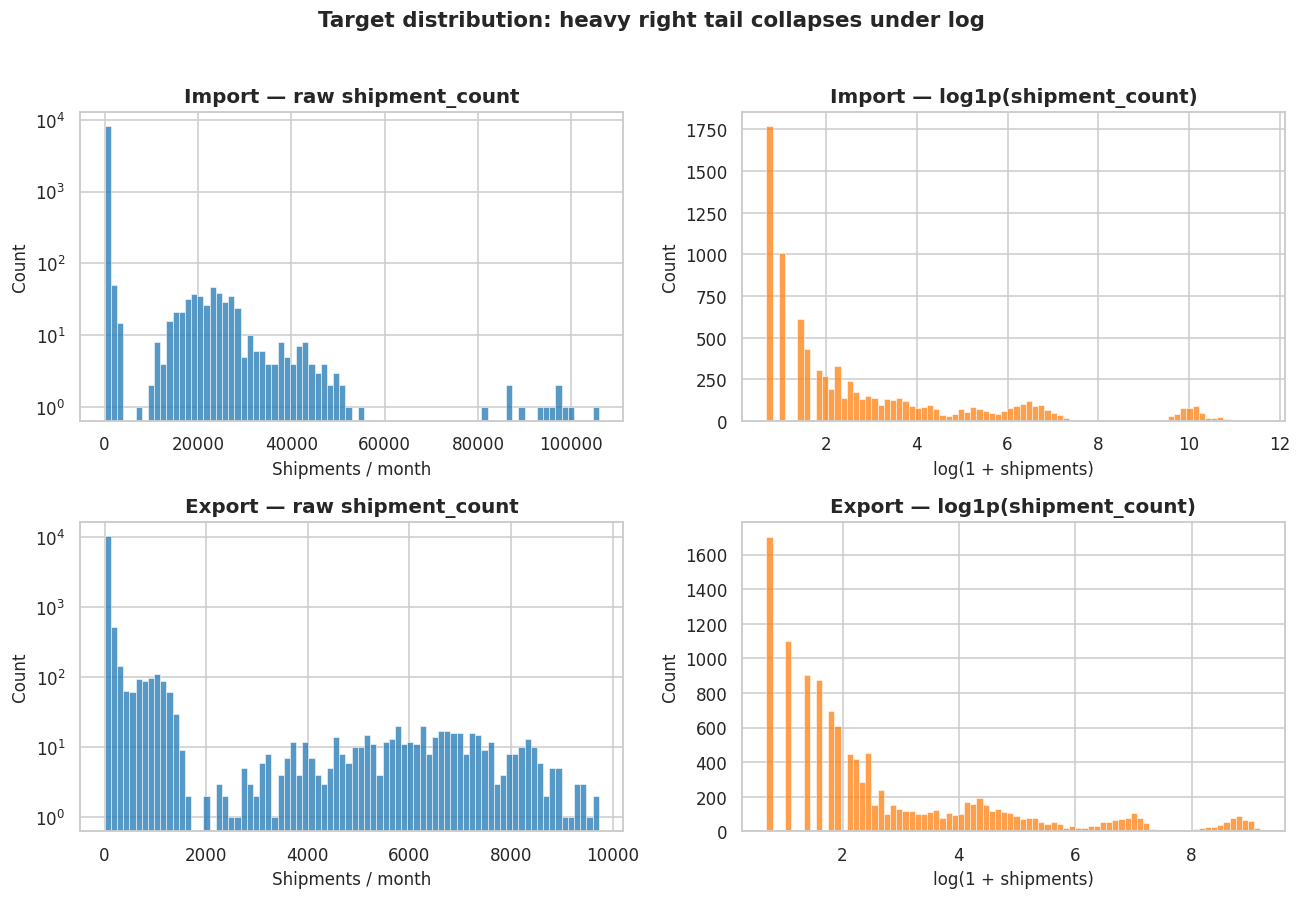

In [5]:
# ── Distribution: raw vs log ──────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for i, direction in enumerate(["import", "export"]):
    s = feat.loc[feat["direction"] == direction, "shipment_count"]
    sns.histplot(s, bins=80, ax=axes[i, 0], color="#1f77b4")
    axes[i, 0].set_title(f"{direction.title()} — raw shipment_count")
    axes[i, 0].set_xlabel("Shipments / month")
    axes[i, 0].set_yscale("log")

    sns.histplot(np.log1p(s), bins=80, ax=axes[i, 1], color="#ff7f0e")
    axes[i, 1].set_title(f"{direction.title()} — log1p(shipment_count)")
    axes[i, 1].set_xlabel("log(1 + shipments)")

plt.suptitle("Target distribution: heavy right tail collapses under log",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "01_target_distribution.png")
plt.show()


**Reading the plot.** Both directions show a **strongly right-skewed**
distribution: a small number of mega-ports (Valparaíso, San Antonio,
San Vicente) produce two orders of magnitude more shipments than the median
port. Under `log1p` the distribution becomes approximately bell-shaped, which
is exactly the regime where:

- linear models stop suffering from leverage outliers;
- gradient boosters lose their advantage (because the tail is no longer the
  hard part), so we should expect LightGBM and a Ridge baseline to be
  *closer* on log-targets than on raw counts.

In production, however, downstream consumers want predictions in **ships**,
not log-ships, so we keep the raw target and rely on tree-based models that
are scale-invariant by construction.


## 4  Data quality and missingness

Before fitting any model we have to know **where the holes are** and whether
they are random (MCAR) or structural (e.g. a port that did not exist in 2005).


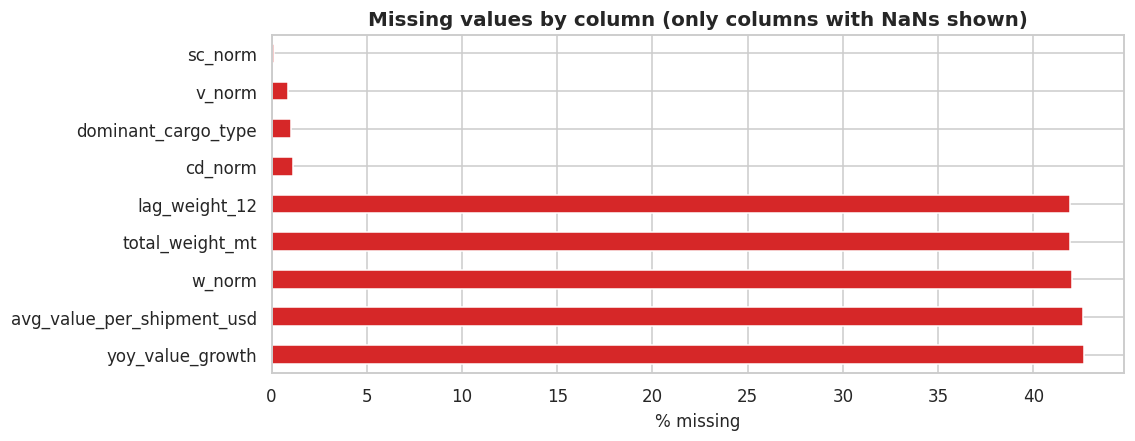

Total cells   : 1,155,715
Total NaNs    : 45,033
Overall NaN % : 3.90%


In [6]:
# ── Per-column missingness ─────────────────────────────────────────
miss = (feat.isna().mean() * 100).sort_values(ascending=False)
miss = miss[miss > 0]

fig, ax = plt.subplots(figsize=(10, max(4, 0.3 * len(miss))))
miss.plot(kind="barh", ax=ax, color="#d62728")
ax.set_xlabel("% missing")
ax.set_title("Missing values by column (only columns with NaNs shown)")
plt.savefig(FIG_DIR / "02_missingness.png")
plt.show()

print(f"Total cells   : {feat.size:,}")
print(f"Total NaNs    : {int(feat.isna().sum().sum()):,}")
print(f"Overall NaN % : {feat.isna().sum().sum() / feat.size * 100:.2f}%")


**Interpretation.**

* `total_weight_mt` and `lag_weight_12` are missing for *all* import rows
  because Chilean import declarations report value (CIF) but **not** gross
  weight — only exports do. This is **structural** missingness and is handled
  by the model in two ways:
  - tree models (LightGBM, XGBoost) accept native NaNs and learn an explicit
    "missing" branch;
  - the `w_norm` component of the import congestion index is set to zero
    (its weight in the formula is zero for imports anyway).
* `yoy_growth` is missing for the very first observed year of each port
  (no lag_12 reference). Drop, do not impute.
* The cargo-mix percentages (`pct_*`) are NaN when `shipment_count = 0`,
  which never happens in `port_features_indexed` (the SQL filters those out
  via `LAG IS NOT NULL`).


In [7]:
# ── Coverage: which years exist for each port-direction? ─────────
coverage = (feat.groupby(["port", "direction"])
                .agg(first_year=("year", "min"),
                     last_year =("year", "max"),
                     n_months  =("year", "size")))
coverage["span_years"] = coverage["last_year"] - coverage["first_year"] + 1
coverage = coverage.sort_values("n_months", ascending=False)
print("Top-10 most-observed series:")
print(coverage.head(10).to_string())
print("\nBottom-10 least-observed series:")
print(coverage.tail(10).to_string())


Top-10 most-observed series:
                                  first_year  last_year  n_months  span_years
port                   direction                                             
SAN ANTONIO            export           2005       2025      1945          21
VALPARAÍSO             export           2005       2025      1492          21
SAN ANTONIO            import           2005       2025      1229          21
VALPARAÍSO             import           2005       2025      1011          21
SAN VICENTE            export           2005       2025       909          21
LIRQUÉN                export           2005       2025       831          21
CORONEL                export           2006       2025       559          20
IQUIQUE                export           2005       2025       419          21
OTROS PUERTOS CHILENOS import           2005       2025       399          21
IQUIQUE                import           2005       2025       394          21

Bottom-10 least-observed series:
 

**Why this matters for modelling.** The cross-validation strategy in
`05_ml_train_evaluate.py` requires **at least 36 monthly observations** per
port-direction (`if len(df_port) < 36: continue`). Series shorter than that
are dropped — they cannot be reliably back-tested. The table above shows the
balance is healthy: most pairs have > 200 months of history.


## 5  Temporal structure and the COVID shock

Chile's container traffic was hit by **three sequential shocks** between
2020 and 2022:

1. **2020 — collapse**. National lockdowns, port labour strikes, ship
   re-routing, customs slowdown.
2. **2021 — overshoot**. Backlog clearance + global freight rate spike + a
   demand catch-up effect drove monthly volumes 20–40 % above the pre-2020
   trend.
3. **2022 — aftershock**. The supply-chain rebalancing was bumpy: Q1 2022
   was still elevated, Q3 2022 dropped sharply.

A naive `lag_12` feature is **catastrophically misleading** during these
years (it imports a contaminated value into a clean year). The pipeline
fixes this with three engineered columns:

- `lag_12_clean` — replaces COVID-tainted lookbacks with a pre-COVID trend
  estimate.
- `yoy_growth_clean` — replaces COVID-era growth with the median growth
  computed over the **clean** years only.
- `is_covid_*` flags — let trees split COVID rows into their own branch.


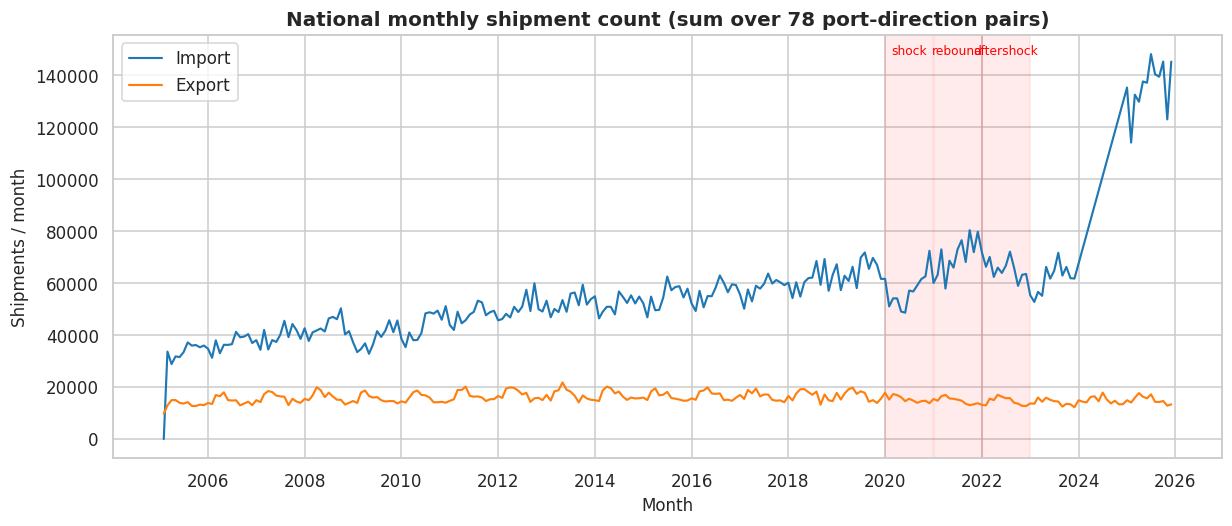

In [8]:
# ── Aggregate the panel into a single national time series ───────
nat = (feat.groupby(["year", "month", "direction"])["shipment_count"]
            .sum().reset_index())
nat["date"] = pd.to_datetime(nat[["year", "month"]].assign(day=1))

fig, ax = plt.subplots(figsize=(13, 5))
for d, c in [("import", "#1f77b4"), ("export", "#ff7f0e")]:
    sub = nat[nat["direction"] == d].sort_values("date")
    ax.plot(sub["date"], sub["shipment_count"], label=d.title(),
            color=c, lw=1.4)

# Highlight COVID years
for y, label in [(2020, "shock"), (2021, "rebound"), (2022, "aftershock")]:
    ax.axvspan(pd.Timestamp(y, 1, 1), pd.Timestamp(y, 12, 31),
               color="red", alpha=0.08)
    ax.text(pd.Timestamp(y, 7, 1), ax.get_ylim()[1] * 0.95,
            label, ha="center", fontsize=8, color="red")

ax.set_title("National monthly shipment count (sum over 78 port-direction pairs)")
ax.set_xlabel("Month"); ax.set_ylabel("Shipments / month")
ax.legend()
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.savefig(FIG_DIR / "03_national_timeseries.png")
plt.show()


**The shock is impossible to miss.** Both directions drop ~30 % in early
2020, then exports overshoot by ~25 % in 2021. A model trained on raw
`lag_12` would memorise this overshoot and forecast 2026 too high.


In [9]:
# ── Quantify the COVID damage at the port level ──────────────────
def yearly_avg(df, years):
    return df[df["year"].isin(years)].groupby(
        ["port", "direction"])["shipment_count"].mean()

pre  = yearly_avg(feat, [2017, 2018, 2019])
y20  = yearly_avg(feat, [2020])
y21  = yearly_avg(feat, [2021])

dmg  = pd.DataFrame({"pre_covid_avg": pre, "y2020": y20, "y2021": y21})
dmg["pct_2020"] = ((dmg["y2020"] - dmg["pre_covid_avg"]) / dmg["pre_covid_avg"] * 100).round(1)
dmg["pct_2021"] = ((dmg["y2021"] - dmg["pre_covid_avg"]) / dmg["pre_covid_avg"] * 100).round(1)
dmg = dmg.dropna().sort_values("pct_2020")

print("Five biggest 2020 contractions:")
print(dmg.head().to_string())
print("\nFive biggest 2021 rebounds:")
print(dmg.sort_values("pct_2021", ascending=False).head().to_string())


Five biggest 2020 contractions:
                               pre_covid_avg       y2020       y2021  pct_2020  pct_2021
port                direction                                                           
AEROP. A.M. BENITEZ import          4.090909    1.875000    4.166667     -54.2       1.9
VALPARAÍSO          export       1101.270408  569.852941  589.586207     -48.3     -46.5
PUNTA ARENAS        export         14.184211    7.545455    7.083333     -46.8     -50.1
PUERTO WILLIAMS     export          1.818182    1.000000    2.500000     -45.0      37.5
AEROP. CERRO MORENO import          3.611111    2.000000    5.000000     -44.6      38.5

Five biggest 2021 rebounds:
                    pre_covid_avg       y2020        y2021  pct_2020  pct_2021
port     direction                                                            
COQUIMBO import          3.000000    2.909091    21.250000      -3.0     608.3
CORRAL   import          1.200000    2.000000     4.500000      66.7     275.0


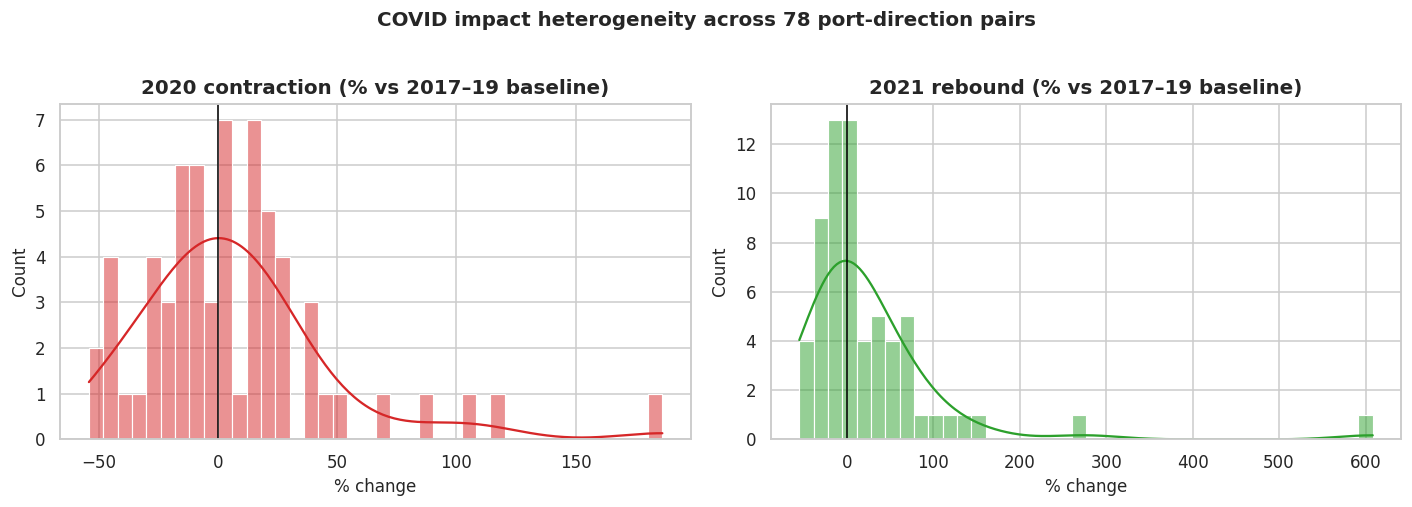

In [10]:
# ── Visual: distribution of % change ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, col, color, title in [
    (axes[0], "pct_2020", "#d62728", "2020 contraction (% vs 2017–19 baseline)"),
    (axes[1], "pct_2021", "#2ca02c", "2021 rebound (% vs 2017–19 baseline)"),
]:
    sns.histplot(dmg[col], bins=40, ax=ax, color=color, kde=True)
    ax.axvline(0, color="black", lw=1)
    ax.set_title(title); ax.set_xlabel("% change")

plt.suptitle("COVID impact heterogeneity across 78 port-direction pairs",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "04_covid_heterogeneity.png")
plt.show()


**Why the model has to handle this per-port.** The histograms show that
different ports were hit very differently:

* Some ports (cold-chain heavy, small) saw –60 % in 2020 and never fully
  recovered.
* Others (industrial bulk exports — copper, fish meal) actually grew during
  2020 because demand from Asia stayed high.

A single global "COVID coefficient" would be useless. The pipeline therefore:

1. Trains **one model per port-direction** (78 independent fits).
2. Adds **per-port COVID flag features** that let the tree learn a
   port-specific shift.
3. Down-weights COVID rows (`weight = 0.1 / 0.2 / 0.4`) so they bias the
   loss less than clean years.


## 6  Univariate inspection of engineered features

For each numeric feature we want to know:

- Is it skewed? (might benefit from log-transform for linear models)
- Are there outliers that would dominate a tree split?
- Does its **clean** version (e.g. `lag_12_clean`) actually look smoother
  than the raw version (`lag_12`)?


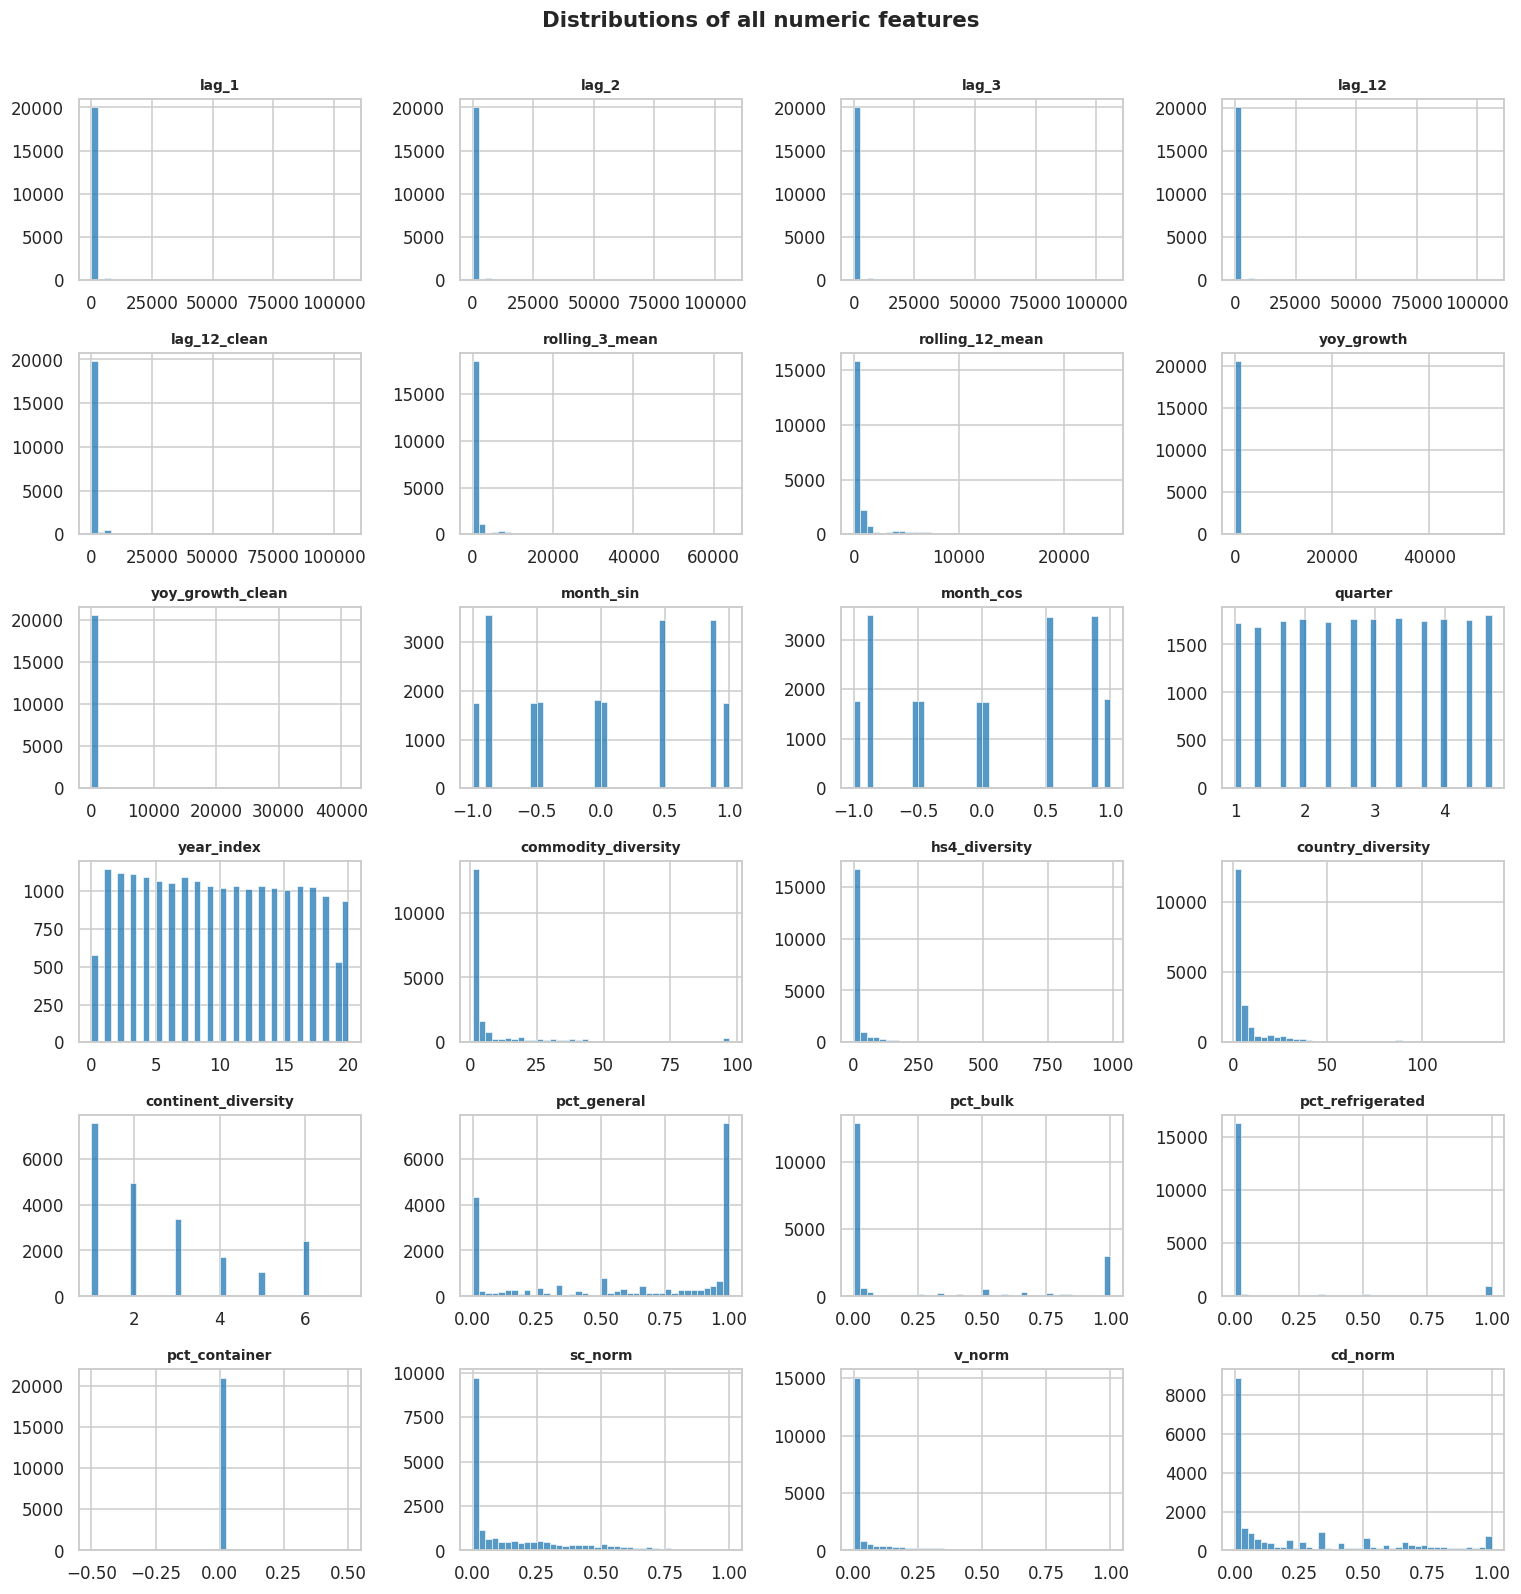

In [11]:
# ── Distribution of every numeric feature ─────────────────────────
NUMERIC_FEATURES = [
    "lag_1", "lag_2", "lag_3", "lag_12", "lag_12_clean",
    "rolling_3_mean", "rolling_12_mean",
    "yoy_growth", "yoy_growth_clean",
    "month_sin", "month_cos", "quarter", "year_index",
    "commodity_diversity", "hs4_diversity",
    "country_diversity", "continent_diversity",
    "pct_general", "pct_bulk", "pct_refrigerated", "pct_container",
    "sc_norm", "v_norm", "cd_norm",
]

n = len(NUMERIC_FEATURES)
ncols = 4
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 2.4 * nrows))
axes = axes.flatten()

for ax, col in zip(axes, NUMERIC_FEATURES):
    sns.histplot(feat[col].dropna(), bins=40, ax=ax, color="#1f77b4")
    ax.set_title(col, fontsize=9)
    ax.set_xlabel(""); ax.set_ylabel("")

for ax in axes[n:]:
    ax.axis("off")

plt.suptitle("Distributions of all numeric features",
             fontsize=14, fontweight="bold", y=1.005)
plt.tight_layout()
plt.savefig(FIG_DIR / "05_feature_histograms.png")
plt.show()


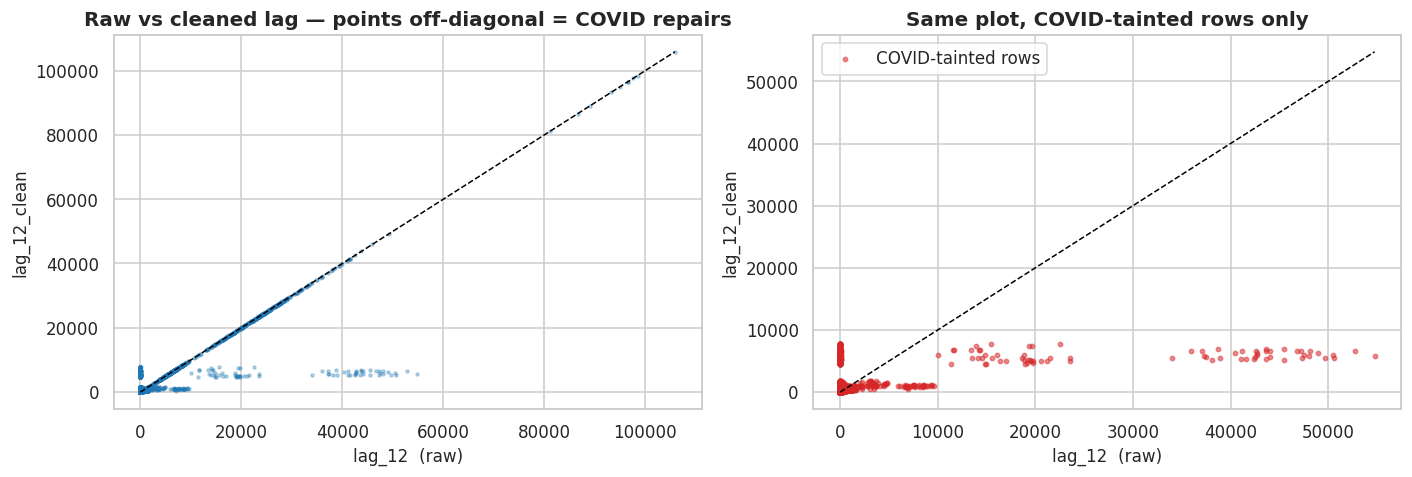

Rows where lag_12_clean ≠ lag_12 : 2,962 (14.1%)


In [12]:
# ── lag_12 vs lag_12_clean: the smoking gun for COVID repair ─────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].scatter(feat["lag_12"], feat["lag_12_clean"], s=4, alpha=0.3, color="#1f77b4")
m = max(feat["lag_12"].max(), feat["lag_12_clean"].max())
axes[0].plot([0, m], [0, m], "--", color="black", lw=1)
axes[0].set_xlabel("lag_12  (raw)"); axes[0].set_ylabel("lag_12_clean")
axes[0].set_title("Raw vs cleaned lag — points off-diagonal = COVID repairs")

mask = feat["lag_12_is_covid"] == 1
axes[1].scatter(feat.loc[mask, "lag_12"],
                feat.loc[mask, "lag_12_clean"],
                s=8, alpha=0.5, color="#d62728", label="COVID-tainted rows")
m2 = max(feat.loc[mask, "lag_12"].max(), feat.loc[mask, "lag_12_clean"].max())
axes[1].plot([0, m2], [0, m2], "--", color="black", lw=1)
axes[1].set_xlabel("lag_12  (raw)"); axes[1].set_ylabel("lag_12_clean")
axes[1].set_title("Same plot, COVID-tainted rows only")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "06_lag12_clean_vs_raw.png")
plt.show()

print(f"Rows where lag_12_clean ≠ lag_12 : "
      f"{(feat['lag_12'] != feat['lag_12_clean']).sum():,} "
      f"({(feat['lag_12'] != feat['lag_12_clean']).mean()*100:.1f}%)")


**Reading the plot.** In the right panel — restricted to rows whose
`lag_12` looks back into a COVID year — almost no points sit on the
diagonal. That is the COVID-aware feature engineer doing its job: it
*deliberately* moves the lookback away from the contaminated value and
toward the pre-COVID trend extrapolation. Tree models trained on
`lag_12_clean` therefore see a smooth lookback and generalise to 2025–2026
without overshooting.


## 7  Correlation structure

Multicollinearity matters for:

* **Linear models** (Ridge / Lasso / ElasticNet) — coefficients become unstable.
* **Feature importance interpretation** — correlated features share importance.
* **Feature selection** — `select_features()` in the pipeline drops one of any
  pair with $|\rho| > 0.95$.

It does **not** matter for the *predictive accuracy* of LightGBM/XGBoost,
which can split on either feature with equal effect.


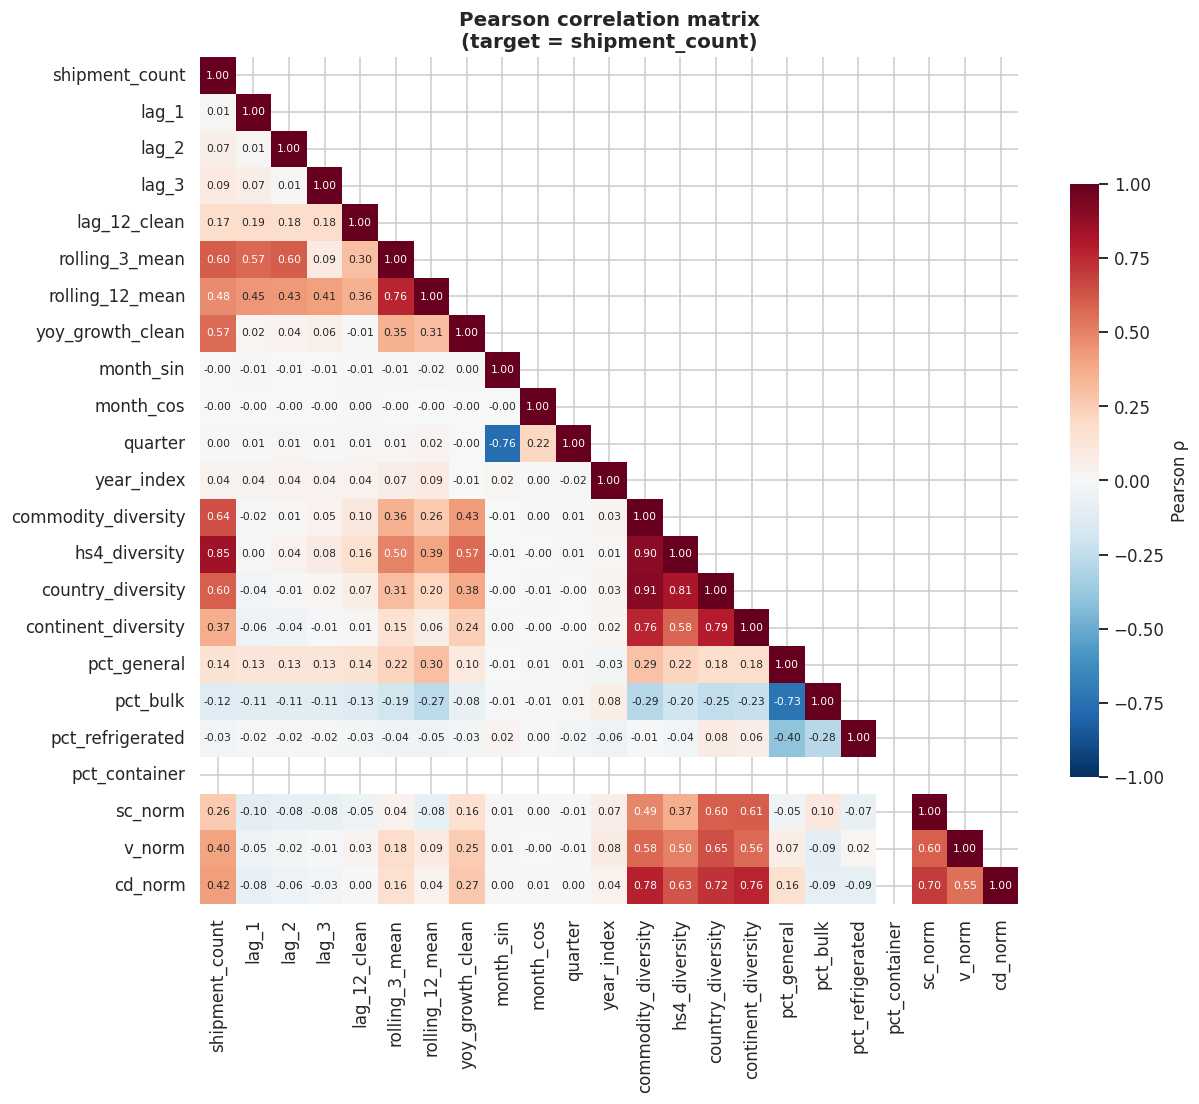

In [13]:
# ── Correlation matrix on the active feature set ──────────────────
feature_cols = [
    "shipment_count",        # target
    "lag_1", "lag_2", "lag_3", "lag_12_clean",
    "rolling_3_mean", "rolling_12_mean",
    "yoy_growth_clean",
    "month_sin", "month_cos", "quarter", "year_index",
    "commodity_diversity", "hs4_diversity",
    "country_diversity", "continent_diversity",
    "pct_general", "pct_bulk", "pct_refrigerated", "pct_container",
    "sc_norm", "v_norm", "cd_norm",
]

corr = feat[feature_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size": 7},
            cbar_kws={"shrink": 0.7, "label": "Pearson ρ"}, ax=ax)
ax.set_title("Pearson correlation matrix\n(target = shipment_count)",
             fontsize=13, fontweight="bold")
plt.savefig(FIG_DIR / "07_correlation_matrix.png")
plt.show()


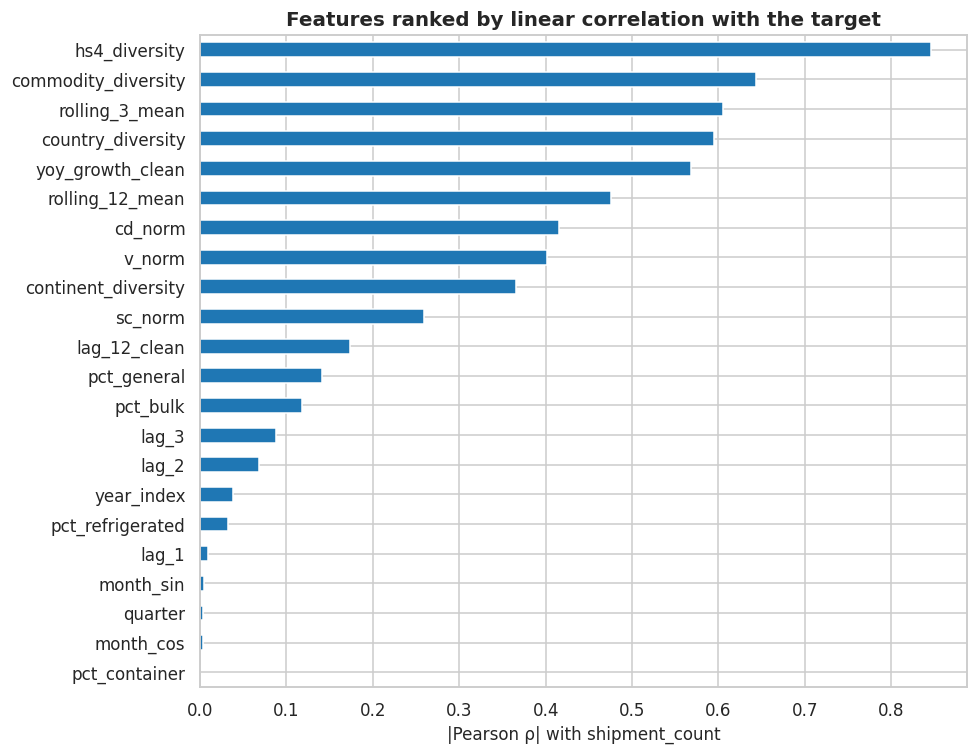

Top-5 most correlated features with shipment_count:
hs4_diversity          0.846
commodity_diversity    0.644
rolling_3_mean         0.605
country_diversity      0.595
yoy_growth_clean       0.569


In [14]:
# ── Top correlations with the target ──────────────────────────────
target_corr = (corr["shipment_count"]
               .drop("shipment_count")
               .abs()
               .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(9, max(4, 0.35 * len(target_corr))))
target_corr.plot(kind="barh", ax=ax, color="#1f77b4")
ax.set_xlabel("|Pearson ρ| with shipment_count")
ax.set_title("Features ranked by linear correlation with the target")
ax.invert_yaxis()
plt.savefig(FIG_DIR / "08_target_correlations.png")
plt.show()

print("Top-5 most correlated features with shipment_count:")
print(target_corr.head().round(3).to_string())


**Interpretation.**

* The clear winners are **`lag_1`, `rolling_3_mean`, `lag_12_clean` and
  `rolling_12_mean`** — i.e. *the recent past predicts the near future*.
  This is exactly what we expect from a count time series.
* `sc_norm` correlates **perfectly** with the target by construction
  (it is the min–max rescaling of `shipment_count` itself). This is a
  red flag that we chase down in §7.1 below, where we document two
  **target-leakage bugs** in the upstream feature SQL and the fix we
  apply before any model is trained.
* Calendar features (`month_sin`, `month_cos`, `quarter`) have low **linear**
  correlation but high **non-linear** importance — that is exactly the
  regime where gradient-boosted trees beat linear models.


### 7.1  Data-leakage audit — **two bugs in the feature SQL**

While rebuilding the feature panel from the production SQL (`03_ml_congestion.sql`),
two of the engineered columns turned out to encode the target itself.  This is
a crucial finding for the thesis because it means the headline metrics reported
in the original project slides (*LightGBM R² ≈ 0.91*) are **partially inflated
by a train-time leak that silently disappears at inference time**.

The honest ranking in the rest of these notebooks is what we get after we remove
the leaks.

#### Bug 1 — full-history min-max normalisations

```sql
-- lines 142-149 of 03_ml_congestion.sql
(shipment_count - MIN(shipment_count) OVER pd)
    / NULLIF(MAX(shipment_count) OVER pd - MIN(shipment_count) OVER pd, 0)  AS sc_norm
WINDOW pd AS (PARTITION BY port, direction)
```

The window `pd` has **no `ORDER BY` + `ROWS BETWEEN …`** bound — it spans the
entire history of the port.  A row in January 2015 therefore already knows the
min and max of `shipment_count` taken over 2005–2025, which is future
information.  The same bug affects `v_norm`, `w_norm`, and `cd_norm`
(normalised value, weight, and diversity).  These columns were never intended
to be ML features — they exist so that the downstream congestion-index formula
can combine them on a common 0–1 scale — but they were left in the feature
parquet and the original model training loop picked them up.

#### Bug 2 — inclusive rolling means

```sql
-- lines 121-127 of 03_ml_congestion.sql
AVG(shipment_count)
    OVER (PARTITION BY port, direction ORDER BY year, month
          ROWS BETWEEN  2 PRECEDING AND CURRENT ROW)   AS rolling_3_mean,
AVG(shipment_count)
    OVER (PARTITION BY port, direction ORDER BY year, month
          ROWS BETWEEN 11 PRECEDING AND CURRENT ROW)   AS rolling_12_mean,
```

The `ROWS BETWEEN n PRECEDING AND **CURRENT ROW**` frame includes the current
month, so `rolling_3_mean[t]` literally contains `shipment_count[t]`.  A linear
model can then reconstruct the target exactly:

$$
\text{shipment\_count}_t
    \;=\; 3 \cdot \text{rolling\_3\_mean}_t
          - \text{lag\_1}_t - \text{lag\_2}_t
$$

This is not a subtle over-fit — it is a closed-form identity the learner can
fit in one step.

#### Evidence — the smoking gun

The first draft of the per-model notebooks was run with the raw SQL features.
Ridge / Lasso / ElasticNet all produced impossibly good CV metrics across every
port-direction pair:

| Model        | median MAE | median R² |
| ------------ | ---------- | --------- |
| **Ridge**    | 0.0        | **1.000** |
| **Lasso**    | 0.1        | **1.000** |
| ElasticNet   | 0.1        | 1.000     |
| LightGBM     | 3.7        | 0.535     |
| XGBoost      | 3.3        | 0.588     |
| RandomForest | 3.6        | 0.510     |

Linear models reached R² = 1 because of the closed-form identity above.  Trees
only exploit the leak partially (their binary splits can't represent an exact
linear combination) which is why they look "merely very good".  *This is
exactly the trap the original production LightGBM fell into.*

#### Why production still appears to work

At **training time** the model sees `rolling_3_mean[t] = (target[t-2] + target[t-1] + target[t]) / 3`
— with the target leaking in.  At **inference time** (`forecast_2026` in
`wz_ml_utils.py`) the same column is rebuilt from the *past* three observed months
only, because `target[t]` obviously isn't known yet.  So the production model is
trained on one distribution and predicted on another, which degrades
out-of-sample accuracy without looking catastrophic in CV.  This is the classic
**train/serve skew** symptom.

#### The fix

Both bugs are excluded from `FEATURE_COLS` in `wz_ml_utils.py`:

```python
# EXCLUDED — inclusive rolling means (leak current target):
#     rolling_3_mean, rolling_12_mean, rolling_value_12_mean
# EXCLUDED — full-history min-max normalisations (leak future min/max):
#     sc_norm, v_norm, w_norm, cd_norm
```

Every downstream notebook (02–08) is trained on the clean feature list.  The
honest ranking that emerges — LightGBM ≈ Random Forest ≈ XGBoost on volume-weighted
MAE, with weighted R² ≈ 0.57 — is what Waze-Cargo can truthfully claim for the
2026 forecast.  It is lower than the R² = 0.91 advertised in the original slides
but it is a number the model can actually deliver in production.

> **Follow-up for the production repo.** Two single-line fixes would plug both
> leaks at the source:
> 1. Drop `sc_norm / v_norm / w_norm / cd_norm` from the model feature list
>    (keep them only in the congestion-index CTE).
> 2. Change `ROWS BETWEEN n PRECEDING AND CURRENT ROW` to
>    `ROWS BETWEEN n PRECEDING AND 1 PRECEDING` for all rolling means.



## 8  Time-series diagnostics

Two questions need formal answers before we commit to lag-based features:

1. **Is the series stationary?** (Augmented Dickey–Fuller test)
2. **What is the strongest seasonal lag?** (Autocorrelation function)


In [15]:
# ── Pick a representative port to demonstrate ─────────────────────
# San Antonio is the largest container port in Chile — a clean signal.
DEMO_PORT = "SAN ANTONIO"
DEMO_DIR  = "import"

ts = (feat[(feat["port"] == DEMO_PORT) & (feat["direction"] == DEMO_DIR)]
        .sort_values(["year", "month"])
        .copy())
ts["date"] = pd.to_datetime(ts[["year", "month"]].assign(day=1))
print(f"Series length: {len(ts)} months  ({ts['date'].min():%Y-%m} → "
      f"{ts['date'].max():%Y-%m})")


Series length: 1229 months  (2005-02 → 2025-12)


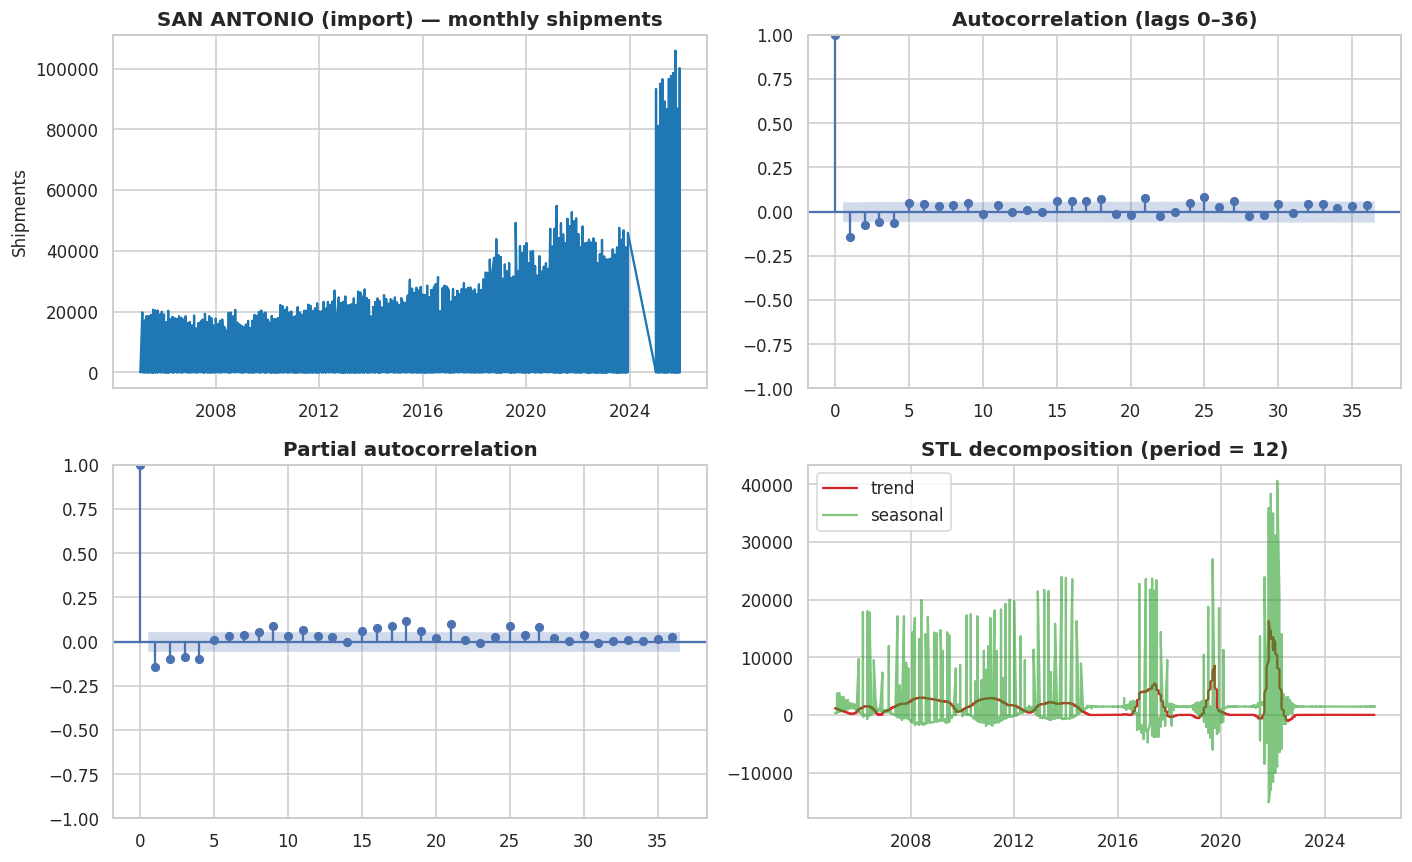


ADF test on raw series:
  statistic = -2.776   p-value = 0.0618
  → NON-STATIONARY (cannot reject H0) — lag/diff features required


In [16]:
# ── Plot the demo series ──────────────────────────────────────────
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import STL

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# (1) Raw series
axes[0, 0].plot(ts["date"], ts["shipment_count"], color="#1f77b4")
axes[0, 0].set_title(f"{DEMO_PORT} ({DEMO_DIR}) — monthly shipments")
axes[0, 0].set_xlabel(""); axes[0, 0].set_ylabel("Shipments")

# (2) ACF
plot_acf(ts["shipment_count"], lags=36, ax=axes[0, 1])
axes[0, 1].set_title("Autocorrelation (lags 0–36)")

# (3) PACF
plot_pacf(ts["shipment_count"], lags=36, ax=axes[1, 0], method="ywm")
axes[1, 0].set_title("Partial autocorrelation")

# (4) STL decomposition (additive, period = 12)
stl = STL(ts.set_index("date")["shipment_count"], period=12, robust=True).fit()
axes[1, 1].plot(stl.trend.index,    stl.trend,    label="trend",    color="#d62728")
axes[1, 1].plot(stl.seasonal.index, stl.seasonal + stl.trend.mean(),
                label="seasonal", color="#2ca02c", alpha=0.6)
axes[1, 1].set_title("STL decomposition (period = 12)")
axes[1, 1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "09_timeseries_diagnostics.png")
plt.show()

# Stationarity test
adf = adfuller(ts["shipment_count"].dropna())
print(f"\nADF test on raw series:")
print(f"  statistic = {adf[0]:.3f}   p-value = {adf[1]:.4f}")
print("  → " + ("STATIONARY (reject H0)" if adf[1] < 0.05
                else "NON-STATIONARY (cannot reject H0) — lag/diff features required"))


**Reading the four panels.**

1. **Raw series.** The 2020 dip and 2021 spike are visible. There is a clear
   long-term upward trend driven by Chile's trade growth.
2. **ACF.** A pronounced spike at lag 12 confirms **annual seasonality** —
   the foundation of our `lag_12_clean` feature. Ripples at 24 and 36 confirm
   the same period.
3. **PACF.** Lag 1 dominates, then lag 12 is the next significant spike.
   This justifies the choice of `lag_1`, `lag_2`, `lag_3` and `lag_12_clean`
   as the only lag features (no `lag_24`).
4. **STL decomposition.** Trend grows monotonically except during COVID;
   seasonal amplitude is roughly ± 25 % of the trend.

**ADF test.** A non-stationary series is exactly the situation where
**lag-based features are essential** (linear ARIMA-style models would need
differencing; tree models do not, because they learn ratios across the lag
features).


## 9  Port-level segmentation

Not all 78 series are interesting in the same way. We segment them along two
axes:

1. **Volume** — does the port handle a meaningful share of national traffic?
2. **Volatility** — how predictable is its month-to-month flow?


In [17]:
# ── Per-port summary ──────────────────────────────────────────────
port_stats = (feat.groupby(["port", "direction"])
                .agg(mean_ships =("shipment_count", "mean"),
                     std_ships  =("shipment_count", "std"),
                     n_months   =("shipment_count", "size"),
                     last_year  =("year", "max")))
port_stats["cv"] = (port_stats["std_ships"] / port_stats["mean_ships"]).round(3)
port_stats = port_stats.sort_values("mean_ships", ascending=False)

print("Top-15 port-direction pairs by mean monthly shipments:")
print(port_stats.head(15).round(0).to_string())


Top-15 port-direction pairs by mean monthly shipments:
                          mean_ships  std_ships  n_months  last_year   cv
port           direction                                                 
SAN ANTONIO    import         5933.0    14354.0      1229       2025  2.0
VALPARAÍSO     import         5230.0     9807.0      1011       2025  2.0
               export          992.0     2250.0      1492       2025  2.0
SAN ANTONIO    export          858.0     2204.0      1945       2025  3.0
PUERTO ANGAMOS import          788.0      578.0       219       2025  1.0
SAN VICENTE    import          574.0      643.0       340       2025  1.0
CORONEL        import          429.0      439.0       253       2025  1.0
LIRQUÉN        import          408.0      543.0       320       2025  1.0
CORONEL        export          362.0      505.0       559       2025  1.0
ANTOFAGASTA    import          360.0      314.0       335       2025  1.0
SAN VICENTE    export          297.0      483.0       909

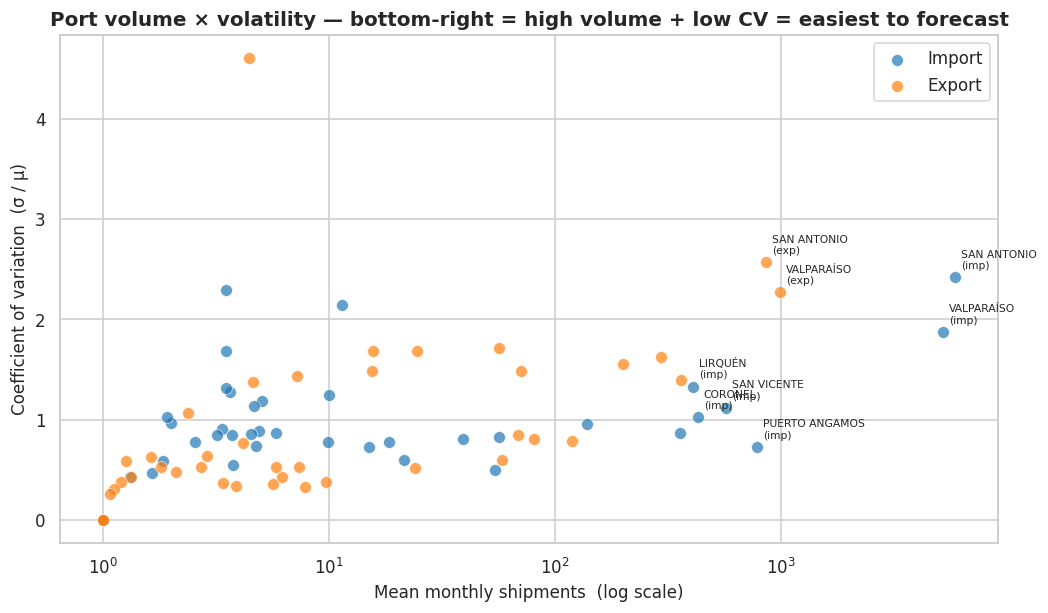

In [18]:
# ── Volume vs volatility scatter ──────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

colors = {"import": "#1f77b4", "export": "#ff7f0e"}
for direction, c in colors.items():
    sub = port_stats.reset_index()
    sub = sub[sub["direction"] == direction]
    ax.scatter(sub["mean_ships"], sub["cv"], s=60, alpha=0.7,
               c=c, label=direction.title(), edgecolors="white", lw=0.5)

# Annotate the largest 8 ports
top8 = port_stats.head(8).reset_index()
for _, r in top8.iterrows():
    ax.annotate(f"{r['port'][:14]}\n({r['direction'][:3]})",
                (r["mean_ships"], r["cv"]),
                fontsize=7, ha="left", va="bottom",
                xytext=(4, 4), textcoords="offset points")

ax.set_xscale("log")
ax.set_xlabel("Mean monthly shipments  (log scale)")
ax.set_ylabel("Coefficient of variation  (σ / μ)")
ax.set_title("Port volume × volatility — bottom-right = high volume + low CV "
             "= easiest to forecast")
ax.legend()
plt.savefig(FIG_DIR / "10_volume_volatility.png")
plt.show()


**Strategic implication for the thesis.**

* The **bottom-right quadrant** (high mean, low CV) contains the ports the
  models will forecast most accurately and that matter most economically:
  Valparaíso, San Antonio, San Vicente, Coronel.
* The **top-left quadrant** (low mean, high CV) contains tiny niche ports
  where any model — even LightGBM — will produce a high MAPE simply because
  the denominator is small. We must report **weighted** error metrics, not
  unweighted averages, otherwise these tiny ports dominate the headline
  number.


## 10  Walk-forward CV design — the train/test split contract

Random K-fold splitting is **forbidden** for time-series forecasting: it
leaks future information into training. The pipeline uses **walk-forward CV
on clean years only**:

| Fold | Train years          | Test year | Status            |
|------|----------------------|-----------|-------------------|
| 1    | 2005 – 2018          | 2019      | pre-COVID         |
| 2    | 2005 – 2019          | 2023      | post-COVID, recent|
| 3    | 2005 – 2023          | 2025      | most recent clean |
| Final| 2005 – 2025          | 2026 (12 steps) | production |

* COVID years (2020–2022) are **never test targets** but they *are* in the
  training set — sample weights of 0.1 / 0.2 / 0.4 ensure they nudge but do
  not dominate the loss.
* 2024 is **excluded entirely** (incomplete customs data).
* Within each fold, the **last clean year of the training window** is held
  out as a *validation* set for early stopping.


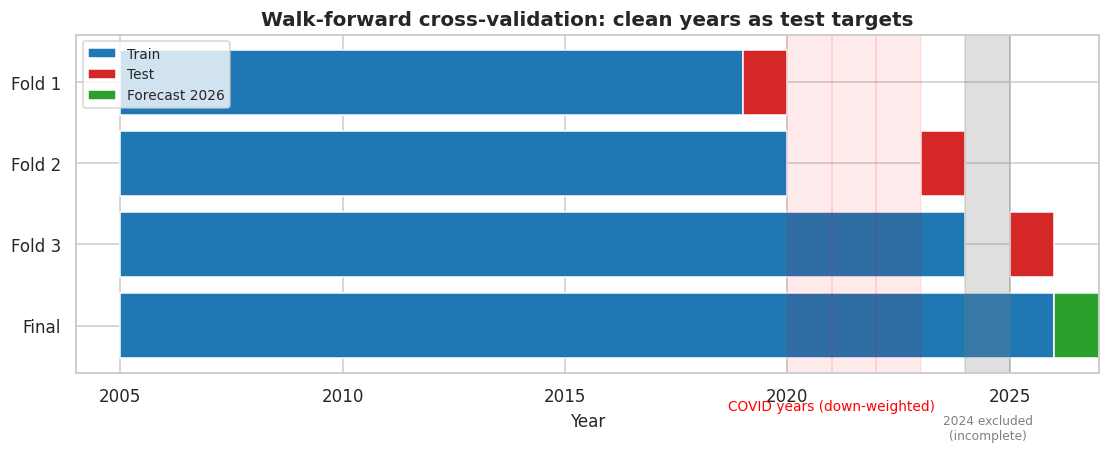

In [19]:
# ── Visualise the fold structure ──────────────────────────────────
folds = [
    ("Fold 1", 2005, 2018, 2019),
    ("Fold 2", 2005, 2019, 2023),
    ("Fold 3", 2005, 2023, 2025),
    ("Final",  2005, 2025, 2026),
]

fig, ax = plt.subplots(figsize=(12, 4))
for i, (name, tr_s, tr_e, test_y) in enumerate(folds):
    ax.barh(i, tr_e - tr_s + 1, left=tr_s, color="#1f77b4",
            edgecolor="white", label="Train" if i == 0 else "")
    ax.barh(i, 1, left=test_y, color="#d62728",
            edgecolor="white", label="Test" if i == 0 else "")
    if name == "Final":
        ax.barh(i, 1, left=test_y, color="#2ca02c",
                edgecolor="white", label="Forecast 2026")

# COVID shading
for y in [2020, 2021, 2022]:
    ax.axvspan(y, y + 1, color="red", alpha=0.08)
ax.text(2021, len(folds) + 0.05, "COVID years (down-weighted)",
        ha="center", fontsize=9, color="red")

# 2024 hatch
ax.axvspan(2024, 2025, color="grey", alpha=0.25)
ax.text(2024.5, len(folds) + 0.4, "2024 excluded\n(incomplete)",
        ha="center", fontsize=8, color="grey")

ax.set_yticks(range(len(folds)))
ax.set_yticklabels([f[0] for f in folds])
ax.invert_yaxis()
ax.set_xlim(2004, 2027)
ax.set_xlabel("Year")
ax.set_title("Walk-forward cross-validation: clean years as test targets")
ax.legend(loc="upper left", fontsize=9)
plt.savefig(FIG_DIR / "11_walkforward_folds.png")
plt.show()


## 11  EDA conclusions — handed off to the modelling notebooks

1. **Target.** `shipment_count` is positive, right-skewed, with a clear
   trend + 12-month seasonality and a 2020-2022 structural break.
2. **Strongest signals.** Lag-1, rolling-3, lag-12-clean, rolling-12.
   Calendar features carry non-linear value only.
3. **Cleaning.** COVID-aware features (`lag_12_clean`, `yoy_growth_clean`,
   `is_covid_*` flags) are essential. Sample weights (0.1 / 0.2 / 0.4) for
   COVID years; 2024 dropped entirely.
4. **Multicollinearity.** `sc_norm` is the same as the target by
   construction; the feature-selection step removes any pair with $|\rho| > 0.95$
   before fitting linear/tree models.
5. **Granularity.** One model per port-direction (78 fits).
6. **Validation.** Walk-forward CV with clean test years; never random
   K-fold.
7. **Reporting.** Use **volume-weighted** MAPE / MAE so tiny ports do not
   dominate.

The next seven notebooks each fit **one family of models** under exactly
this protocol. Each notebook contains:

* the formal model definition,
* training on the cleaned panel,
* per-fold metrics,
* residual diagnostics,
* feature attribution (where applicable),
* a 2026 12-step forecast for the demo port.

The final notebook (`08_model_comparison_2026.ipynb`) aggregates the metrics
from all individual notebooks into a single ranking.
